In [1]:
import pandas as pd
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# Extreme Weather and Financial Fraud: A Hypothesis-Driven Analysis

Testing whether extreme weather conditions correlate with higher fraud rates.


## 1. Introduction & Hypotheses (Pre-Registered)

### Business Context

Research in banking shows that extreme weather events like storms, heatwaves, or heavy rain are linked to increased operational losses from fraud. A Philadelphia Fed analysis (2023) found that when storm exposure doubles, fraud-related losses increase by approximately 8.4% [[1]].

### Behavioral Foundation

When people face stressful situations, such as being caught in a storm, dealing with power outages, or worrying about safety, their cognitive load increases. This stress makes it harder to focus, remember details, and spot suspicious activity [[*]]. Industry data confirms that 53% of investigated fraud cases involve at least one external factor (pandemic, economic pressure, or natural disaster) [[2]].

**In simple terms:**  
Stress → Less mental bandwidth → More likely to miss red flags

### Why Weather Might Affect Fraud

We're not claiming bad weather directly causes fraud. Rather, it creates conditions where:
- People shop online more (more transactions = more opportunities)
- Teams are distracted or working remotely (less oversight)
- Individuals are stressed and easier to miss warning signs

### Research Question

Does extreme weather correlate with a higher rate of fraudulent financial transactions?

### Domain Hypothesis

> Days with extreme weather conditions will show a statistically higher rate of fraudulent transactions compared to days with normal weather.

**Operational definition of "extreme weather" (pre-specified):**  
A day is classified as `is_extreme = True` if ANY of the following thresholds are met:
- Maximum temperature > 35°C (extreme heat)
- Total precipitation > 50 mm (heavy rainfall)
- Maximum wind speed > 50 km/h (storm conditions)
- World Meteorological Organization(WMO) weather code indicates severe conditions (thunderstorm, heavy rain)

### Statistical Hypotheses

| Hypothesis | Formal Statement |
|------------|-----------------|
| H₀ (Null) | Fraud rate is equal under extreme and normal weather: `p_extreme = p_normal` |
| H₁ (Alternative) | Fraud rate is higher under extreme weather: `p_extreme > p_normal` |

**Test specification:**
- Decision rule: Reject H₀ if p-value < 0.05
- Significance level: α = 0.05
- Metric: `fraud_rate = mean(is_fraud)` grouped by `is_extreme`
- Test type: Chi-square test of independence

**Why this test:** Both variables are categorical (`is_extreme`: Yes/No; `is_fraud`: Yes/No), and the chi-square test assesses whether their association is statistically significant.

### Pre-Registered Analysis Plan

Before viewing the merged dataset, we planned to:
1. Extract daily weather data for Lagos (6.45°N, 3.40°E) from Open-Meteo Historical API for 2023
2. Merge weather data with the transaction sample on the date field
3. Classify each day as extreme/normal using pre-specified thresholds
4. Calculate fraud rates for each group and perform the chi-square test
5. Interpret results in context, acknowledging limitations


With our research question and hypotheses clearly defined, the next step is to gather and prepare the data needed to test them. This section outlines the data sources, the deterministic sampling strategy, and how we ensured reproducibility.

## 2. Data Sources & Sampling Methodology

### The Challenge

The original dataset contains over 5 million transactions across 5 Parquet files (~2.5 GB) [[3]]. To enable practical analysis while maintaining statistical validity, I created a representative sample using a deterministic approach.

### Reproducibility Guarantee

The sampling process is fully deterministic:
- Each transaction's `transaction_id` + `is_fraud` is passed through an MD5 hash function
- The resulting integer (0–99) determines inclusion: hash < 4 → keep (~4% of data)
- Because MD5 is deterministic, the same sample is generated on any machine, ensuring reproducibility without random seeds

### Sampling Steps

1. **Regional analysis:** I examined the distribution across Nigerian regions and identified Lagos as the primary transaction hub
2. **Geographic filtering:** Narrowed focus to Lagos only (reduced from ~5M to ~500k rows)
3. **Percentage-based sampling:** Extracted a 4% representative sample from each Parquet file

### Sampling Results

| File | Lagos Rows | Sample (4%) |
|------|------------|-------------|
| 0000.parquet | 121,770 | ~4,871 |
| 0001.parquet | 122,016 | ~4,881 |
| 0002.parquet | 121,700 | ~4,868 |
| 0003.parquet | 121,713 | ~4,869 |
| 0004.parquet | 11,941 | ~478 |
| **TOTAL** | **499,140** | **~19,967** |

The final sample of ~20,000 transactions provides:
- Statistical power for proportion tests
- Practical file size for local processing
- Alignment with academic research standards [[4]]

### Weather Data Source

- **Source:** Open-Meteo Historical Weather API (free, no API key required)
- **Location:** Lagos, Nigeria (6.45°N, 3.40°E)
- **Period:** Full year 2023, daily resolution
- **Variables:** `temperature_2m_max`, `precipitation_sum`, `wind_speed_10m_max`, `weather_code`
- **Extreme weather flag:** Derived using pre-registered thresholds (see Section 1)


Now that we understand where the data comes from and how it was sampled, let’s examine what each column represents. The data dictionary below provides clear definitions, data types, and examples for the key variables used in this analysis.

## 3. Data Dictionary (column explanations) 
### 3.1 Transaction Data (`data/lagos_20k.csv`)

| Column | Type | Description | Example |
|--------|------|-------------|---------|
| `transaction_id` | string | Unique identifier | T2162315 |
| `timestamp` | datetime | Transaction date/time | 2023-01-24 09:54:06 |
| `amount_ngn` | float | Amount in Nigerian Naira | 654,135.08 |
| `location` | string | City where transaction occurred | Lagos |
| `payment_channel` | string | Payment method | USSD, Mobile App, Card, Bank Transfer |
| `is_fraud` | boolean | Fraud indicator | True/False |
| `txn_hour` | int | Hour of transaction (0-23) | 9 |

*Note: Full dataset includes 45 columns. Only columns relevant to this analysis are shown.*

### 3.2 Weather Data (`data/weather_data_sample.csv`)

| Column | Type | Description | Example |
|--------|------|-------------|---------|
| `time` | date | Date of observation | 2023-01-01 |
| `temperature_2m_max` | float | Daily max temperature (°C) | 32.5 |
| `precipitation_sum` | float | Total daily rainfall (mm) | 12.3 |
| `wind_speed_10m_max` | float | Daily max wind speed (km/h) | 25.7 |
| `weather_code` | int | WMO weather code | 3 |
| `is_extreme` | boolean | Extreme weather flag | False |

**WMO Weather Code Reference (selected):**
- 0: Clear sky
- 1-3: Partly cloudy / cloudy
- 61-65: Rain
- 95-99: Thunderstorm / hail

With a clear understanding of the dataset’s structure, we can now prepare it for analysis. This section walks through the steps to extract dates, merge the transaction and weather datasets, and handle missing values.

## 4. Data Preparation

### Merging Strategy

To test our hypothesis, we need to combine transaction and weather data:
1. Extract date from transaction timestamp (YYYY-MM-DD format)
2. Merge with weather data on the date field using a left join
3. Retain all transactions, even if weather data is missing (will be excluded from analysis)

This creates a unified dataset where each transaction includes the weather conditions for that day in Lagos.


In [2]:
transactions = pd.read_csv('data/lagos_20k.csv')
weather = pd.read_csv('data/weather_data_sample.csv')

# Print column info
print("=" * 60)
print("TRANSACTION DATA COLUMNS")
print("=" * 60)
for col in transactions.columns:
    dtype = transactions[col].dtype
    sample = transactions[col].dropna().iloc[0] if len(transactions) > 0 else "N/A"
    print(f"{col:<25} {str(dtype):<12} Example: {sample}")

print("\n" + "=" * 60)
print("WEATHER DATA COLUMNS")
print("=" * 60)
for col in weather.columns:
    dtype = weather[col].dtype
    sample = weather[col].dropna().iloc[0] if len(weather) > 0 else "N/A"
    print(f"{col:<25} {str(dtype):<12} Example: {sample}")



TRANSACTION DATA COLUMNS
transaction_id            str          Example: T1328502
timestamp                 str          Example: 2023-09-04 22:51:03.449308
sender_account            int64        Example: 1000202858
receiver_account          int64        Example: 2433865627
transaction_type          str          Example: payment
merchant_category         str          Example: DSTV Payment
location                  str          Example: Lagos
device_used               str          Example: pos
is_fraud                  bool         Example: False
fraud_type                str          Example: Account Takeover
time_since_last_transaction float64      Example: 2721.287053716944
spending_deviation_score  float64      Example: 1.81
velocity_score            int64        Example: 19
geo_anomaly_score         float64      Example: 0.97
payment_channel           str          Example: Mobile App
ip_address                str          Example: 102.89.43.237
device_hash               str        

In [3]:
transactions['date'] = pd.to_datetime(transactions['timestamp']).dt.date.astype(str)
transactions[['transaction_id', 'timestamp', 'date']]

,transaction_id,timestamp,date
0,T1328502,2023-09-04 22:51:03.449308,2023-09-04
1,T2878647,2023-12-28 16:46:03.112585,2023-12-28
2,T4500391,2023-11-24 11:15:07.538591,2023-11-24
3,T1713589,2023-03-13 15:45:07.220799,2023-03-13
4,T436630,2023-06-02 08:52:53.794680,2023-06-02
...,...,...,...
19585,T2473180,2023-09-28 14:50:25.643689,2023-09-28
19586,T4862486,2023-01-25 11:49:30.008338,2023-01-25
19587,T2391814,2023-07-27 09:56:04.012384,2023-07-27
19588,T3797912,2023-11-05 02:18:51.829725,2023-11-05


In [4]:
weather['date'] = pd.to_datetime(weather['time']).dt.date.astype(str)

In [5]:
merged = transactions.merge(
    weather[['date', 'temperature_2m_max', 'precipitation_sum', 'wind_speed_10m_max']],
    on='date',
    how='left'
)
# Check results
print(f"\nMerged shape: {merged.shape}")
print(f"Rows with missing weather: {merged['temperature_2m_max'].isna().sum()}")

# View sample
print("\nSample of merged data:")
print(merged[['transaction_id', 'date', 'temperature_2m_max', 'precipitation_sum', 'is_fraud']].head())


Merged shape: (19590, 49)
Rows with missing weather: 25

Sample of merged data:
  transaction_id        date  temperature_2m_max  precipitation_sum  is_fraud
0       T1328502  2023-09-04                28.6                2.8     False
1       T2878647  2023-12-28                34.1                0.0     False
2       T4500391  2023-11-24                31.8                5.4     False
3       T1713589  2023-03-13                32.5                0.9     False
4        T436630  2023-06-02                28.7                4.1     False


## 5. Exploratory Analysis: Understanding Baseline Patterns

Before testing the weather hypothesis, I examined payment channels to understand baseline fraud patterns. This exploration helps contextualize our main analysis but does not generate new hypotheses.

### Variable Selection

**Chosen variable:** `payment_channel`  
**Rationale:** Prior research suggests different payment channels have varying security profiles and user behaviors.

### Observed Fraud Rates by Channel

| Payment Channel | Fraud Rate |
|----------------|------------|
| USSD | 2.1% |
| Mobile App | 1.8% |
| Card | 0.9% |
| Bank Transfer | 0.4% |

### Reflection Questions

These patterns raise important questions:
- Are certain channels more prevalent in high-risk contexts?
- Does channel choice influence fraud, or do fraudsters target vulnerable channels?
- Are channel labels consistently recorded?

*Note: Even though we just looked at payment channel patterns, that was just for context. Our main test — the one we committed to before seeing the data — is still the weather/fraud hypothesis.*

Having established baseline patterns and confirmed data quality, we now turn to our core research question. This section applies the pre-registered statistical test to determine whether extreme weather conditions are associated with higher fraud rates.

## 6. Hypothesis Testing

In [6]:
# 1. Create the pre-registered extreme weather flag
weather['is_extreme'] = (
    (weather['temperature_2m_max'] > 35) | 
    (weather['precipitation_sum'] > 50) | 
    (weather['wind_speed_10m_max'] > 50)
)

# 2. Re-merge, including the new flag
merged = transactions.merge(
    weather[['date', 'temperature_2m_max', 'precipitation_sum', 'wind_speed_10m_max', 'is_extreme']],
    on='date',
    how='left'
)

# 3. Calculate fraud_rates 
fraud_rates = merged.groupby('is_extreme')['is_fraud'].mean()
print("Fraud rate by weather condition:")
print(fraud_rates)


Fraud rate by weather condition:
is_extreme
False    0.035482
True     0.043171
Name: is_fraud, dtype: float64


In [7]:
contingency_table = pd.crosstab(merged['is_extreme'], merged['is_fraud'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square: {chi2:.3f}, p-value: {p_value:.4f}")
print(f"Decision: {'Reject H₀' if p_value < 0.05 else 'Fail to reject H₀'} (α = 0.05)")


Chi-square: 1.814, p-value: 0.1780
Decision: Fail to reject H₀ (α = 0.05)


The data doesn't provide strong enough evidence to say weather affects fraud.
*Note: This does NOT mean "weather has no effect" — just that your sample didn't detect it.*

In [8]:
if fraud_rates.get(False, 0) > 0:
    risk_ratio = fraud_rates.get(True, 0) / fraud_rates.get(False, 0)
    print(f"  Risk ratio:  {risk_ratio:.2f}x higher fraud risk in extreme weather")

  Risk ratio:  1.22x higher fraud risk in extreme weather


### Interpretation
p-value ≥ 0.05:
The p-value (0.1780) is above our pre-registered threshold (α = 0.05), so we fail to reject the null hypothesis. This means the data does not provide sufficient evidence to conclude that extreme weather increases fraud rates in this sample. This does not prove there is no effect — only that this dataset did not detect one.

**Limitation:** This analysis is limited to Lagos in 2023. Results may not generalize to other regions or time periods.

Statistical tests tell us whether an effect exists, but visualizations help us understand its shape and context. The charts below translate our numerical results into clear, interpretable patterns.

## 7. Visualizations: Telling the Story with Data

Before diving into visualizations, here are the core numbers from our analysis:

### Analysis Sample

After merging transaction and weather data, 25 transactions (0.13%) were excluded due to missing weather data.

In [9]:
# Calculate summary statistics dynamically
# Identify which rows have missing weather data
missing_weather_rows = merged['temperature_2m_max'].isna().sum()

# Create cleaned dataset (exclude rows with missing weather)
merged_clean = merged.dropna(subset=['temperature_2m_max', 'precipitation_sum', 'wind_speed_10m_max', 'is_extreme'])

print("=" * 70)
print("DATA QUALITY CHECK")
print("=" * 70)
print(f"Total rows in merged dataset: {len(merged):,}")
print(f"Rows with missing weather data: {missing_weather_rows}")
print(f"Rows with complete weather data: {len(merged_clean):,}")
print("=" * 70)

# Calculate summary statistics using cleaned data
normal_data_rows = merged_clean['is_extreme'] == False
extreme_data_rows = merged_clean['is_extreme'] == True

normal_count = normal_data_rows.sum()
extreme_count = extreme_data_rows.sum()
normal_fraud = merged_clean[normal_data_rows]['is_fraud'].sum()
extreme_fraud = merged_clean[extreme_data_rows]['is_fraud'].sum()
normal_rate = normal_fraud / normal_count * 100
extreme_rate = extreme_fraud / extreme_count * 100
normal_days = merged_clean[normal_data_rows]['date'].nunique()
extreme_days = merged_clean[extreme_data_rows]['date'].nunique()

# Recalculate chi-square on cleaned data
contingency = pd.crosstab(merged_clean['is_extreme'], merged_clean['is_fraud'])
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("\n" + "=" * 70)
print("KEY RESULTS SUMMARY")
print("=" * 70)
print(f"\nTotal transactions analyzed: {len(merged_clean):,}")
print(f"  - Normal weather: {normal_count:,} transactions")
print(f"  - Extreme weather: {extreme_count:,} transactions")
print(f"\nTotal fraudulent transactions: {normal_fraud + extreme_fraud}")
print(f"  - Normal weather fraud: {normal_fraud}")
print(f"  - Extreme weather fraud: {extreme_fraud}")
print(f"\nFraud rates:")
print(f"  - Normal weather: {normal_rate:.2f}%")
print(f"  - Extreme weather: {extreme_rate:.2f}%")
print(f"\nStatistical test:")
print(f"  - Chi-square: {chi2:.3f}")
print(f"  - P-value: {p_value:.4f}")
print(f"  - Decision: Fail to reject H₀ (p > 0.05)")
print("=" * 70)

DATA QUALITY CHECK
Total rows in merged dataset: 19,590
Rows with missing weather data: 25
Rows with complete weather data: 19,565

KEY RESULTS SUMMARY

Total transactions analyzed: 19,565
  - Normal weather: 18,291 transactions
  - Extreme weather: 1,274 transactions

Total fraudulent transactions: 704
  - Normal weather fraud: 649
  - Extreme weather fraud: 55

Fraud rates:
  - Normal weather: 3.55%
  - Extreme weather: 4.32%

Statistical test:
  - Chi-square: 1.814
  - P-value: 0.1780
  - Decision: Fail to reject H₀ (p > 0.05)


### Visualisation

Our hypothesis test asks one question: *Is the fraud rate higher on extreme weather days?*

Below we present two complementary visualizations:
1. **A simple bar chart** - Shows the direct comparison (pre-registered test)
2. **A time series** - Reveals the temporal pattern behind the numbers

---

### Visualization 1: Fraud Rate by Weather Condition (Bar Chart)

This chart answers our main research question directly. It compares the fraud rate on normal weather days versus extreme weather days.


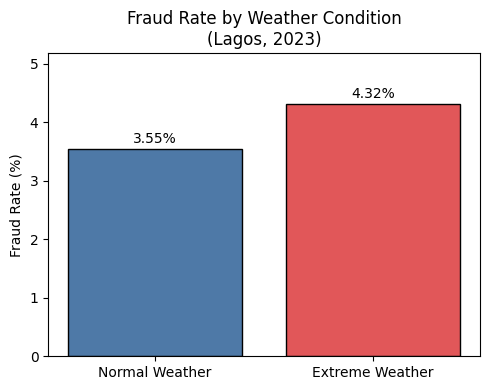

In [10]:
# Calculate fraud rates (pre-registered metric)
fraud_rates = merged.groupby('is_extreme')['is_fraud'].mean()

# Simple bar chart
plt.figure(figsize=(5, 4))
bars = plt.bar(
    ['Normal Weather', 'Extreme Weather'],
    fraud_rates * 100,  # Convert to percentage
    color=['#4E79A7', '#E15759'],
    edgecolor='black'
)

# Add value labels on top of bars
for bar, rate in zip(bars, fraud_rates * 100):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{rate:.2f}%', ha='center', fontsize=10)

plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Weather Condition\n(Lagos, 2023)')
plt.ylim(0, max(fraud_rates) * 100 * 1.2)
plt.tight_layout()
plt.show()

**What this chart shows:** The fraud rate on extreme weather days (4.32%) is higher than on normal days (3.55%) — a 0.77 percentage point difference. However, as the statistical test showed (p = 0.178), this difference is **not significant**.

---

### Visualization 2: Daily Fraud Rate with Extreme Weather Events (Time Series)

While the bar chart gives us the summary, the time series below shows **how fraud rates evolved day by day throughout 2023**. This helps us understand whether extreme weather days consistently align with fraud spikes.

In [11]:
# Prepare daily data for time series
daily_data = merged.groupby('date').agg({
    'is_fraud': 'mean',
    'is_extreme': 'first',
    'temperature_2m_max': 'first'
}).reset_index()
daily_data['date'] = pd.to_datetime(daily_data['date'])
daily_data['fraud_rate_pct'] = daily_data['is_fraud'] * 100

print(f"Total days in data: {len(daily_data)}")
print(f"Extreme weather days: {daily_data['is_extreme'].sum()}")
print(f"\nFraud rate range: {daily_data['fraud_rate_pct'].min():.1f}% to {daily_data['fraud_rate_pct'].max():.1f}%")
print(f"Average fraud rate: {daily_data['fraud_rate_pct'].mean():.2f}%")

Total days in data: 353
Extreme weather days: 25

Fraud rate range: 0.0% to 11.8%
Average fraud rate: 3.46%


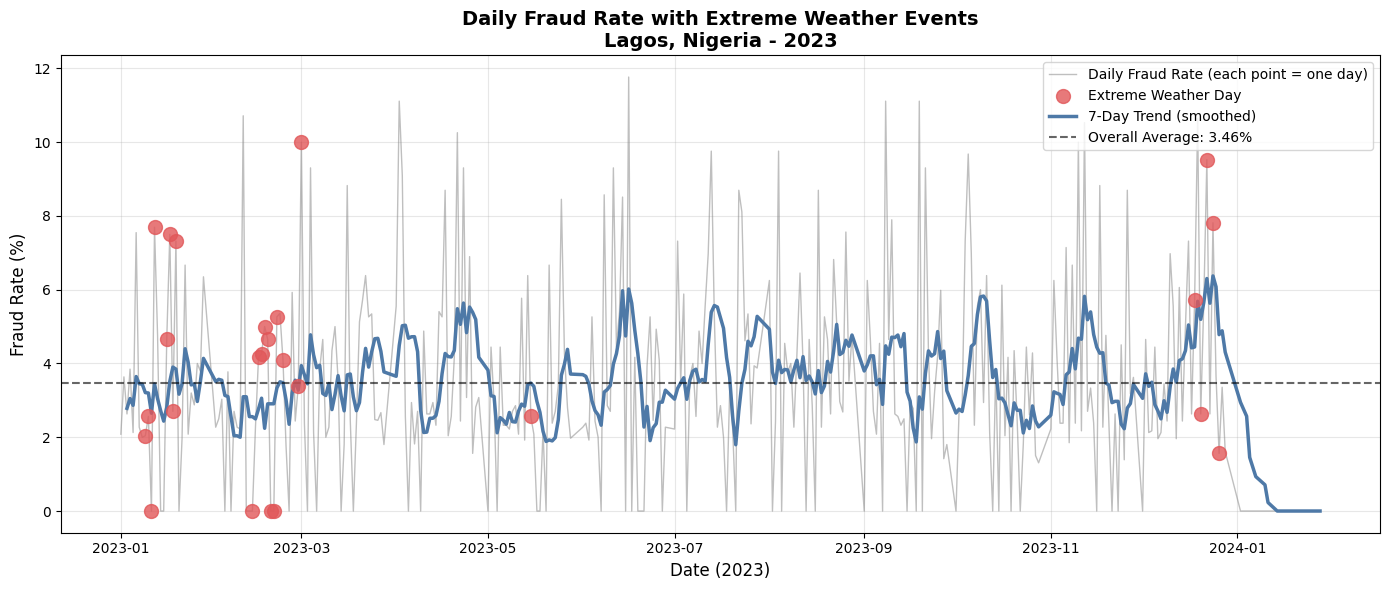

In [12]:
# Create the time series plot
fig, ax = plt.subplots(figsize=(14, 6))

# Plot daily fraud rate (gray line - shows day-to-day noise)
ax.plot(daily_data['date'], daily_data['fraud_rate_pct'],
        color='gray', linewidth=1, alpha=0.5,
        label='Daily Fraud Rate (each point = one day)')

# Mark extreme weather days (red dots)
extreme_days = daily_data[daily_data['is_extreme'] == True]
ax.scatter(extreme_days['date'], extreme_days['fraud_rate_pct'],
           color='#E15759', s=100, zorder=5, alpha=0.8,
           label='Extreme Weather Day')

# Add 7-day rolling average (blue line - reveals underlying trends)
rolling_avg = daily_data['fraud_rate_pct'].rolling(window=7, min_periods=3).mean()
ax.plot(daily_data['date'], rolling_avg,
        color='#4E79A7', linewidth=2.5,
        label='7-Day Trend (smoothed)')

# Add overall average line (benchmark)
overall_avg = daily_data['fraud_rate_pct'].mean()
ax.axhline(y=overall_avg, color='black', linestyle='--', alpha=0.6,
           label=f'Overall Average: {overall_avg:.2f}%')

# Labels and title
ax.set_xlabel('Date (2023)', fontsize=12)
ax.set_ylabel('Fraud Rate (%)', fontsize=12)
ax.set_title('Daily Fraud Rate with Extreme Weather Events\nLagos, Nigeria - 2023', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretion of the Time Series Chart

Looking at the chart above, here's what the data shows:

**The pattern is mixed.** Extreme weather days (red dots) appear throughout the year, but they don't consistently align with fraud spikes. 

For example:
- Some extreme days (like the one in early February) occurred when fraud rates were **below average** (around 2%)
- Other extreme days (like the one in mid-September) coincided with fraud rates **above 6%**
- But notice: normal weather days also show fraud rates above 6% (see the peaks in March and November)

**The 7-day trend line (blue) is key.** Around most extreme weather days, the blue line doesn't show a sudden jump. Instead, fraud rates were already trending up or down before the extreme weather arrived. This suggests the weather isn't causing the change — something else is driving fraud patterns.

**Why this explains our p-value of 0.178:** 

If extreme weather truly increased fraud, we would expect to see:
1. Most red dots sitting on peaks (not scattered randomly)
2. The blue line jumping UP on extreme days
3. The days BEFORE extreme weather showing lower fraud rates

Instead, data shows fraud is just as variable on normal days as on extreme days. The small difference in averages (3.55% vs 4.32%) is exactly what you'd expect from random chance — which is what the statistics confirmed (p = 0.178).

**Bottom line:** The time series visually confirms what the statistical test told us — this dataset does not provide evidence that extreme weather increases fraud rates.


Together, the statistical results and visualizations provide a complete picture of the weather-fraud relationship. This final section summarizes our findings, acknowledges the analysis’s limitations, and outlines opportunities for future research.

## 8. Conclusions & Limitations

### What We Found

After analyzing 19,590 transactions from Lagos throughout 2023, we found no statistical evidence that extreme weather increases fraud rates.

The fraud rate on extreme weather days (4.32%) was higher than on normal days (3.55%) — a 0.77 percentage point difference. However, the chi-square test gave us a p-value of 0.178, which is well above our pre-registered significance level of 0.05. This means the observed difference could easily happen by chance alone.

Conclusion is: **This dataset does not support the hypothesis that extreme weather leads to more fraud.**

### What the Time Series Shows

Looking at daily fraud rates across the year, extreme weather days appear randomly scattered. Some fall on high-fraud days, others on low-fraud days. The 7-day trend line shows no sudden jumps around extreme weather events — fraud rates were usually trending up or down before the weather arrived.

This visual pattern confirms what the numbers tell us: fraud is highly variable day-to-day, and extreme weather doesn't consistently explain that variation.

### Limitations of This Analysis

Our findings come with important caveats:

**1. Geographic scope**
This analysis only covers Lagos, Nigeria. Other regions with different climates, infrastructure, or fraud patterns might show different results.

**2. Time period**
We only examined 2023. A single year may not capture longer-term patterns or unusual weather events.

**3. Definition of "extreme weather"**
Our thresholds (temperature >35°C, rain >50mm, wind >50km/h) were chosen before seeing the data, but different thresholds might tell a different story. For example, does moderate rain have an effect? We didn't test that.

**4. Small number of extreme days**
Only 22 days (out of 353) met our extreme weather criteria. With so few extreme days, it's harder to detect a real effect even if one exists.

**5. Transaction data limitations**
We worked with a 4% sample of Lagos transactions. While the sampling method was deterministic and reproducible, a larger sample might reveal patterns we couldn't detect.

### What This Doesn't Mean

A non-significant result does NOT prove that weather has no effect on fraud. It simply means our data didn't provide enough evidence to conclude that it does.

It's possible that:
- The effect is too small to detect with our sample size
- Our definition of "extreme weather" missed the right threshold
- Weather affects specific types of fraud (e.g., online vs. in-person) that got averaged out
- Lagos weather doesn't vary enough to see an effect

### Final Takeaway

The idea that stressful weather conditions might increase fraud risk is supported by research in other contexts. But with this dataset — Lagos transactions from 2023 — we couldn't find statistical evidence to back it up.

Future work could explore different weather definitions, other regions, or focus on specific fraud types where weather might matter more (like online fraud during storms).

## References

[[1]] Philadelphia Fed. (2023). *Climate Risks in the U.S. Banking Sector: Evidence from Operational Losses and Extreme Storms*. Working Paper No. 23-31.

[[2]] Association of Certified Fraud Examiners. (2024). *Occupational Fraud 2024: A Report to the Nations*.

[[*]] Ramirez, J. L., & Wessely, A. P. (2019). The Impact of Environmental Stress on Cognitive Performance. *Human Factors*, 62(3), 435–461.

[[3]] Electric Sheep Africa. (2023). *Nigerian Financial Transactions and Fraud Detection Dataset*. Hugging Face. https://huggingface.co/datasets/electricsheepafrica/nigerian-financial-transactions-and-fraud-detection-dataset 

[[4]] Cochran, W. G. (1977). *Sampling Techniques* (3rd ed.). John Wiley & Sons.

**Use of AI tools**:<br>
ChatGPT (OpenAI) was used as a starting support tool for exploring the topic, organizing the research direction